# Overview

`oplanet` is a python package implemented for querying databases necessary for research in exoplanetary science. The package is still under development, and therefor it has only limited capabilities:
- querying the *Simbad* database for checking star aliases and properties.
- querying the *NASA Exoplanet Archive* database for orbital parameters of information about the planetary system
- querying the *SVO* database for filters (and saving the information to cache, as the database is often down)

The query of *Vizier* for photometric points is currenlty unavailable, as the API has recently changed.

## Installation

This package is available on pip:
```bash
pip install oplanet
```

## Quick start

In [1]:
from oplanet import *
from oakley import * # not necessary, just pretty prints

The program complains because the NASA Exoplanet Archive needs to be downloaded. For this, run:

In [2]:
NSystem.refresh()

[?] Deleted 2026-05-04_nasa-exoplanet-archive.csv.
[~] Loading data from NASA Exoplanet Archive (should take about 60s...) (40.790s)


The long waiting time is not necessarly a result of your internet connect, it might also be the server executing the TAP query taking time. Anyway, you don't need to run this very often (however, the `oplanet` package will warn you if the loaded database it old and might need updating).

In [1]:
from oplanet import *

[!] Archive file is older than 50 days. Please refresh it with the `NSystem.refresh()` static method.


Again, simply run the `NSystem.refresh` method.

In [2]:
NSystem.refresh()

[?] Deleted 2026-01-04_nasa-exoplanet-archive.csv.
[~] Loading data from NASA Exoplanet Archive (should take about 60s...) (00:01:39)


If the file is found to be too old, the package will also display a warning (the database is cached locally, but it might need to be updated).

`oplanet` is now ready to be used. Let's start simple and check the queries to Simbad.

## The Simbad API

This API is very simple and doesn't offer advanced options. You can simply retrieve the distance, the coordinates, and the aliases of a given star.

In [2]:
star_name = "bet Pic"
parsed_star_name = parse_star_name(star_name)
star_aliases = get_star_aliases(star_name)
distance_pc = get_distance_pc(star_name)
coords = get_star_coords(star_name)

Message(f"Results of queries to {star_name}:").list({
    "Star Name": parsed_star_name, # closest Simbad valid name
    "Aliases": star_aliases,
    "Distance (pc)": distance_pc,
    "Coordinates (RA, Dec)": coords
})

[i] Results of queries to bet Pic:
 > Star Name:             * bet Pic
 > Aliases:               ['HD 39060', 'HIP 27321', 'GJ 219', 'GJ 219.0', 'HR 2020', '2MASS J05471708-5103594', 'TYC 8099-1392-1', 'SAO 234134', 'TIC 270577175', 'WISEA J054717.10-510358.4', 'Gaia DR3 4792774797545800832', 'PLX 1339', '* bet Pic', 'CD-51 1620', 'CPC 0 3123', 'CPD-51 774', 'GC 7287', 'GCRV 3614', 'GEN# +1.00039060', 'GSC 08099-01392', 'HIC 27321', 'IRAS 05460-5104', 'JP11 1271', 'CNS5 1437', 'PPM 334622', 'ROT 934', 'SKY# 9519', 'TD1 5440', 'UBV 5954', 'UBV M 11539', '[DML87] 189', 'uvby98 100039060', 'Gaia DR2 4792774797545105664', 'JCMTSE J054716.8-510356', 'PLX 1339.00', 'PSCz P05460-5104', 'Renson 10480', 'AKARI-IRC-V1 J0547170-510359', 'WISE J054717.01-510357.5', 'WEB 5372', 'JCMTSF J054716.8-510402']
 > Distance (pc):         19.63452298908124
 > Coordinates (RA, Dec): (np.float64(86.82119870875), np.float64(-51.066511426388885))


## The SVO API
Retrieving filter information from SVO can also be a pain, espacially when the website is down. Hence, the code caches them in a `json` file. Some filters are automatically downloaded on the first time the code runs. Once downloaded, you can directly use the name of the filter, without specifying facility or instrument.

[i] Filter F1140C properties:
 > ID:                       JWST/MIRI.F1140C
 > Facility:                 JWST
 > Instrument:               MIRI
 > Mean wavelength (m):      1.1316e-05
 > Pivot wavelength (m):     1.1310e-05
 > Effective wavelength (m): 1.1301e-05
 > Effective bandwidth (m):  6.0365e-07
 > Bandwidth (m):            1.7666e-07
 > Detector type:            energy_counter


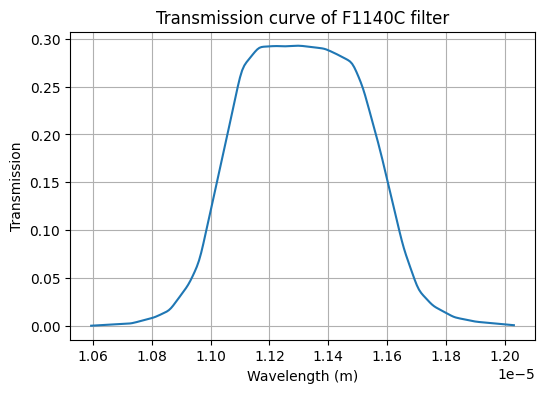

In [3]:
filter = SFilter("F1140C")
filter.display()
filter.plot()

If you want to check all filters for a given facility and/or instrument, you can run:

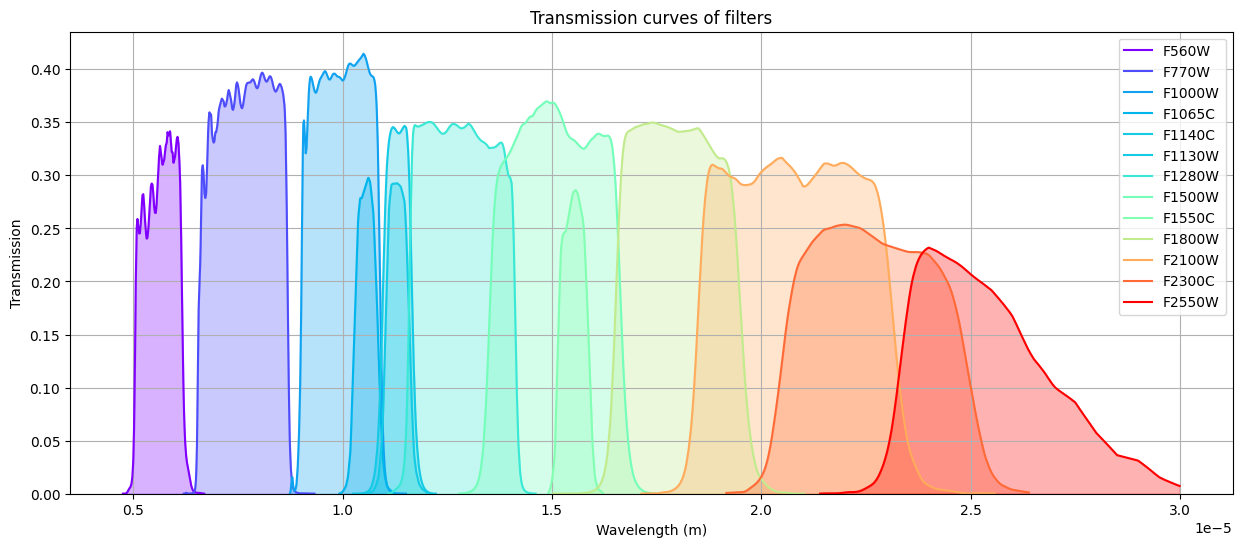

In [4]:
miri_filters = SFilter.get_filters("JWST", "MIRI")
SFilter.plot_all([filter.id for filter in miri_filters])

To retrieve a filter that hasn't been downloaded yet, you need to specify the facility.

In [7]:
filter = SFilter("F158", facility="Roman")

[i] Found 10 filters for specified criteria (facility=Roman). Building dictionnaries and caching them locally...
[~] Loading transmission curves for Roman...
 > [%] [0.622s > 0.000s, 16.1 it/s, 10/10]                                              
 > [~] Task completed after: 0.673s


Several properties can be used to retrieve the different important wavelengths. Wavelength are always returned in meters.

## The NASA Exoplanet Archive API

The exoplanet archive provides plenty of informations on planetary systems, stars and planets. Let's check the star `LHS 1140`.

In [1]:
from oplanet import *
from oakley import *

system = NSystem("LHS 1140")
Message.print(f"Example: {system.distance_pc}")
system.display()

Example: [14.9861  0.0153 -0.0152]
[i] Looking at system properties
 > Star name:             LHS 1140
 > Number of planets:     2
 > Dataframe shape:       (12, 355)
 > Star:                  <NStar(LHS 1140, 12 rows)>
 > Planets:               [<NPlanet(LHS 1140 c, 6 rows)>, <NPlanet(LHS 1140 b, 6 rows)>]
 > Distance (pc):         [14.9861  0.0153 -0.0152]
 > Parallax (mas):        [66.6996     0.0673611 -0.0673611]
 > Coordinates (RA, Dec): (11.2486, -15.2741)
 > Reference:             TICv8
 > Row:                   0/11


The output format of the properties of the objects querying the archive is the following:
- if a measured value is known for the retireved parameter, the returned format is: `[value, error_upper, error_lower]` with `error_lower` being negative.
- if no measured value is known, the return format is: `[np.nan, upper_limit, np.nan]` or `[np.nan, np.nan, lower_limit]` depending on the value provided in the Nasa Exoplanet Archive

Stellar information can be accessed as well.

In [2]:
star = system.star
star.display()

[i] Star LHS 1140 properties:
 > Age (Myr):                               [  nan   nan 5000.]
 > Mass (solar masses):                     [ 0.1844  0.0045 -0.0045]
 > Radius (solar radii):                    [ 0.2159  0.003  -0.003 ]
 > Luminosity (solar luminosities):         [-2.42022  0.033   -0.03572]
 > Effective temperature (K):               [3096.   48.  -48.]
 > Irradiation temparature at 1 arcsec (K): [17.91910267  0.14173005 -0.14665736]
 > Metallicity (dex):                       [-0.15  0.09 -0.09]
 > Spectral type:                           nan
 > Reference:                               Cadieux et al. 2024
 > Row:                                     6/11


Here, `LHS 1140` has no known age, but we know it is at least 5000 Myr.
Finally, one can check the planets.

In [3]:
system.b.display()

[i] Planet LHS 1140 b properties:
 > Letter:                       b
 > Discovery year:               2017
 > Discovery method:             Transit
 > Controversial:                False
 > Orbital period (yrs):         [ 6.77260507e-02  1.12251882e-06 -1.09514031e-06]
 > Mass (Mjup):                  [ 0.02007372  0.00144732 -0.00138439]
 > Mass sin(i) (Mjup):           [ 0.01916128  0.00151025 -0.00147879]
 > Semi-major axis (AU):         [ 0.0957  0.0019 -0.0019]
 > Eccentricity:                 [  nan 0.096   nan]
 > Inclination (deg):            [ 8.9877e+01  4.9000e-02 -4.5000e-02]
 > Argument of periastron (deg): [nan nan nan]
 > Time of periastron (JD):      [nan nan nan]
 > RV amplitude (m/s):           [ 4.21  0.24 -0.24]
 > Radius (Rjup):                [ 0.14586518  0.00410385 -0.00410385]
 > Reference:                    Lillo-Box et al. 2020
 > Row:                          5/5


### Data retrieval strategies 

As shown above, the data is taken from a single row of the dataset (the third out of five rows for LHS 1140). This is because orbital measurments are related to one another and to hypothesis made during the analysis. Therefor, one cannot just pick values from different rows, and must stay inside one.

But these parameters might also be related to measurments for the star. And `system.star` might not correspond to it. The solution is to access the `planet.star` property, which will return the same type of object as `system.star`, but this time with only one row available, the one currently used for the planetary parameters.

In [4]:
system.b.star.display()

[i] Star LHS 1140 properties:
 > Age (Myr):                               [nan nan nan]
 > Mass (solar masses):                     [ 0.191  0.012 -0.011]
 > Radius (solar radii):                    [ 0.2134  0.0036 -0.0034]
 > Luminosity (solar luminosities):         [-2.48812  0.01446 -0.01495]
 > Effective temperature (K):               [2988.   67.  -67.]
 > Irradiation temparature at 1 arcsec (K): [17.19359867  0.23603519 -0.23574955]
 > Metallicity (dex):                       [-0.262  0.104 -0.104]
 > Spectral type:                           nan
 > Reference:                               Lillo-Box et al. 2020
 > Row:                                     0/0


But how does the row get chosen in the first place? The algorithm looks through all relevant properties and checks:
- data availability
- precision of the measurments based on the error bars

and makes a choice based on this. However, some MCMC procedures might return arbitrarely low error bars and might bias our analysis, hence we can set options to drive different choices by the algorithm.

### Custom data retrievals

For instance, for LHS 1140b, I don't want to use the parameters from *Lillo-Box et al. 2020*, but want those from *Dittmann et al. 2017*. I can specify this in the planet parameters.

In [5]:
from oplanet import *
system = NSystem("LHS 1140")
planet = system.b
planet.add_reference_priority(
    "Ditt", 2017
)
planet.display()

[i] Planet LHS 1140 b properties:
 > Letter:                       b
 > Discovery year:               2017
 > Discovery method:             Transit
 > Controversial:                False
 > Orbital period (yrs):         [ 6.77265435e-02  6.84462697e-07 -6.84462697e-07]
 > Mass (Mjup):                  [ 0.02092314  0.00572633 -0.00572633]
 > Mass sin(i) (Mjup):           [nan nan nan]
 > Semi-major axis (AU):         [ 0.0875  0.0041 -0.0041]
 > Eccentricity:                 [ nan 0.29  nan]
 > Inclination (deg):            [ 8.9912e+01  7.1000e-02 -7.1000e-02]
 > Argument of periastron (deg): [nan nan nan]
 > Time of periastron (JD):      [nan nan nan]
 > RV amplitude (m/s):           [ 5.34  1.1  -1.1 ]
 > Radius (Rjup):                [ 0.12757605  0.0089214  -0.0089214 ]
 > Reference:                    Dittmann et al. 2017
 > Row:                          4/5


Let's take a look at the choice made by `oplanet`. For each row, a score is computed, counting how good the row is (rating reference matching, the existence of measurments specified in the config, the existence of error bars (or limits), and the range of error bars).

In [6]:
planet.display_config()
planet.display_priorities()

[i] Current configuration for 'planet':
 > [i] References priority:
 >> 0: Ditt_2017
 > [i] Properties priority:
 >> star.age_myr:       1
 >> system.distance_pc: 1
 >> orbital_period_yrs: 2
 >> mass_sini_mjup:     1
 >> mass_mjup:          3
 >> sma_au:             2
 >> eccentricity:       1
 >> inclination_deg:    1
 >> arg_periastron_deg: 1
 >> time_periastron_jd: 1
 >> rv_amplitude_ms:    1
 > [i] Fallback: False
 > [i] Order authors: True
[?] Row priorities for planet: (ref-match, val-notna, err-notna, err-range)
 > 0: Row 4: Dittmann et al. 2017 --> (1, 10, 29.0, 0.375)
 > 1: Row 5: Lillo-Box et al. 2020 --> (0, 11, 29.5, 0.5909090909090909)
 > 2: Row 3: Cadieux et al. 2024 --> (0, 10, 29.0, 0.825)
 > 3: Row 0: Ment et al. 2019 --> (0, 10, 29.0, 0.5916666666666667)
 > 4: Row 2: Kokori et al. 2023 --> (0, 4, 12.0, 0.7708333333333334)
 > 5: Row 1: ExoFOP --> (0, 3, 7.5, 0.4444444444444444)


Here, for row n°4, the algorithm recognizes the provided reference, and thus preferes the *Dittmann et al. 2017" paper. One can also provide a second reference.

In [7]:
planet.add_reference_priority(
    "Lillo" # not necessary to provide a date
)
planet.display_priorities()

[?] Row priorities for planet: (ref-match, val-notna, err-notna, err-range)
 > 0: Row 4: Dittmann et al. 2017 --> (2, 10, 29.0, 0.375)
 > 1: Row 5: Lillo-Box et al. 2020 --> (1, 11, 29.5, 0.5909090909090909)
 > 2: Row 3: Cadieux et al. 2024 --> (0, 10, 29.0, 0.825)
 > 3: Row 0: Ment et al. 2019 --> (0, 10, 29.0, 0.5916666666666667)
 > 4: Row 2: Kokori et al. 2023 --> (0, 4, 12.0, 0.7708333333333334)
 > 5: Row 1: ExoFOP --> (0, 3, 7.5, 0.4444444444444444)


Now *Dittmann* has a reference score of 2, because it appears first in the list of `oplanet`. You can disable this *preference* for the first reference with:

In [8]:
planet.set_order_authors(False)
planet.display_priorities()

[?] Row priorities for planet: (ref-match, val-notna, err-notna, err-range)
 > 0: Row 5: Lillo-Box et al. 2020 --> (1, 11, 29.5, 0.5909090909090909)
 > 1: Row 4: Dittmann et al. 2017 --> (1, 10, 29.0, 0.375)
 > 2: Row 3: Cadieux et al. 2024 --> (0, 10, 29.0, 0.825)
 > 3: Row 0: Ment et al. 2019 --> (0, 10, 29.0, 0.5916666666666667)
 > 4: Row 2: Kokori et al. 2023 --> (0, 4, 12.0, 0.7708333333333334)
 > 5: Row 1: ExoFOP --> (0, 3, 7.5, 0.4444444444444444)


Now Lillo-Box is prefered because it has more values. It also has the age limit, hence the 0.5 advantage in *err-notna*. Finally, over all values and errors that are non nans, *Lillo* has, averaged over the different values, a better precision than 59% of the available measurements.

Let's get the star information as well!

In [9]:
star.reset_config() # removes the priorities and resets to the default config
star.add_reference_priority("Lillo") # no need to specify the date, all matching dates will count
star.display()

[i] Star LHS 1140 properties:
 > Age (Myr):                               [nan nan nan]
 > Mass (solar masses):                     [ 0.191  0.012 -0.011]
 > Radius (solar radii):                    [ 0.2134  0.0036 -0.0034]
 > Luminosity (solar luminosities):         [-2.48812  0.01446 -0.01495]
 > Effective temperature (K):               [2988.   67.  -67.]
 > Irradiation temparature at 1 arcsec (K): [17.19359867  0.23603519 -0.23574955]
 > Metallicity (dex):                       [-0.262  0.104 -0.104]
 > Spectral type:                           nan
 > Reference:                               Lillo-Box et al. 2020
 > Row:                                     4/11


Age Myr is not provided here, but we can ask for an auto-fill of missing values based on other rows.

In [10]:
star.set_fallback(True)
star.display()

[i] Star LHS 1140 properties:
 > Age (Myr):                               [  nan   nan 5000.]
 > Mass (solar masses):                     [ 0.191  0.012 -0.011]
 > Radius (solar radii):                    [ 0.2134  0.0036 -0.0034]
 > Luminosity (solar luminosities):         [-2.48812  0.01446 -0.01495]
 > Effective temperature (K):               [2988.   67.  -67.]
 > Irradiation temparature at 1 arcsec (K): [17.19359867  0.23603519 -0.23574955]
 > Metallicity (dex):                       [-0.262  0.104 -0.104]
 > Spectral type:                           nan
 > Reference:                               Lillo-Box et al. 2020
 > Row:                                     4/11


Not provided value can be filled automatically with the fill method. Let's check an other example!

In [11]:
system = NSystem("Beta Pictoris")
planet = system.b

planet.reset_config()
Message.title("No priorities", "!")
with Message("Without specified preference"):
    planet.display()
    planet.display_priorities()

Message.title("With priorities", "!")
planet.set_config(
    properties={
        "orbital_period_yrs":1,
        "mass_mjup":1,
        "eccentricity":1,
        "inclination_deg":1,
        "sma_au":1
    }
)
with Message("With preferences for certain properties"):
    planet.display()
    planet.display_priorities()




---------------------
!-- No priorities --!
---------------------

[i] Without specified preference
 > [i] Planet bet Pic b properties:
 >> Letter:                       b
 >> Discovery year:               2008
 >> Discovery method:             Imaging
 >> Controversial:                False
 >> Orbital period (yrs):         [23.59345522  0.25104832 -0.20638064]
 >> Mass (Mjup):                  [11.729  2.337 -2.135]
 >> Mass sin(i) (Mjup):           [nan nan nan]
 >> Semi-major axis (AU):         [10.018  0.082 -0.076]
 >> Eccentricity:                 [ 0.106  0.007 -0.006]
 >> Inclination (deg):            [ 8.9009e+01  1.2000e-02 -1.2000e-02]
 >> Argument of periastron (deg): [21.835  4.099 -4.044]
 >> Time of periastron (JD):      [ 2.44802234e+06  1.56350000e+01 -2.47100000e+01]
 >> RV amplitude (m/s):           [ 78.791  15.672 -14.126]
 >> Radius (Rjup):                [nan nan nan]
 >> Reference:                    Feng et al. 2022
 >> Row:                          6/9
 > [?

Finally, values that are empty can be filled automatically the following way.

In [12]:
import numpy as np
values = {
    "Full data": [10, 0.1, -0.2],
    "No errors": [10, np.nan, np.nan],
    "Only lower limit": [np.nan, np.nan, 9],
    "No value": [np.nan, np.nan, np.nan]
}

with Message("Examples with the fill method:"):
    for label, val_array in values.items():
        filled_value = NSystem.fill(
            val_array,
            rel_uncertainty=0.3,
            default_value=9.5
        )
        Message(f"{label}: {val_array} --> {filled_value}")

[i] Examples with the fill method:
 > [i] Full data: [10, 0.1, -0.2] --> [10.   0.1 -0.2]
 > [i] No errors: [10, nan, nan] --> [10.  3. -3.]
 > [i] Only lower limit: [nan, nan, 9] --> [11.7  2.7 -2.7]
 > [i] No value: [nan, nan, nan] --> [ 9.5   2.85 -2.85]


It is possible to change the default preferences by changing the following variable (this dictionnary is synchronized with a json file).

In [13]:
oplanet_config["planet"]["fallback"] = True
oplanet_config._dump() # save the config after updating it (the __setattr__ method of the config wasn't called here)
# this will however not update the "temporary" config used in NSystem, you need to re-import the package
# otherwise you can use:
# oplanet_temp_config.update(
#     oplanet_config
# )

Finally, one can reset the global preferences to their default state (to prevent code from other scripts from leaking).

In [14]:
oplanet_config.reset()

## The Vizier API

If one wants to know the flux of a given star in a filter, `oplanet` also provides an API for querying the Vizier database (inside a region of 2 arcseconds), retrieve photometric points and discard anomalies. Here is an example:

[#] Retrieving photometry for star L 98-59 with radius 2 arcsec
 > 184 photometric measurements retrieved.
 > 100 points dropped (keeping only WISE:W1, WISE:W2, ...).
 > 66 duplicate points dropped.
 > [i] Choosing 8 points out of 18 to enforce concavity of SED...
 >> [%] [0.189s > 0.000s, 52.9 it/s, 10/10]                                              
[~] Fitting spline to photometry... (0.000s)


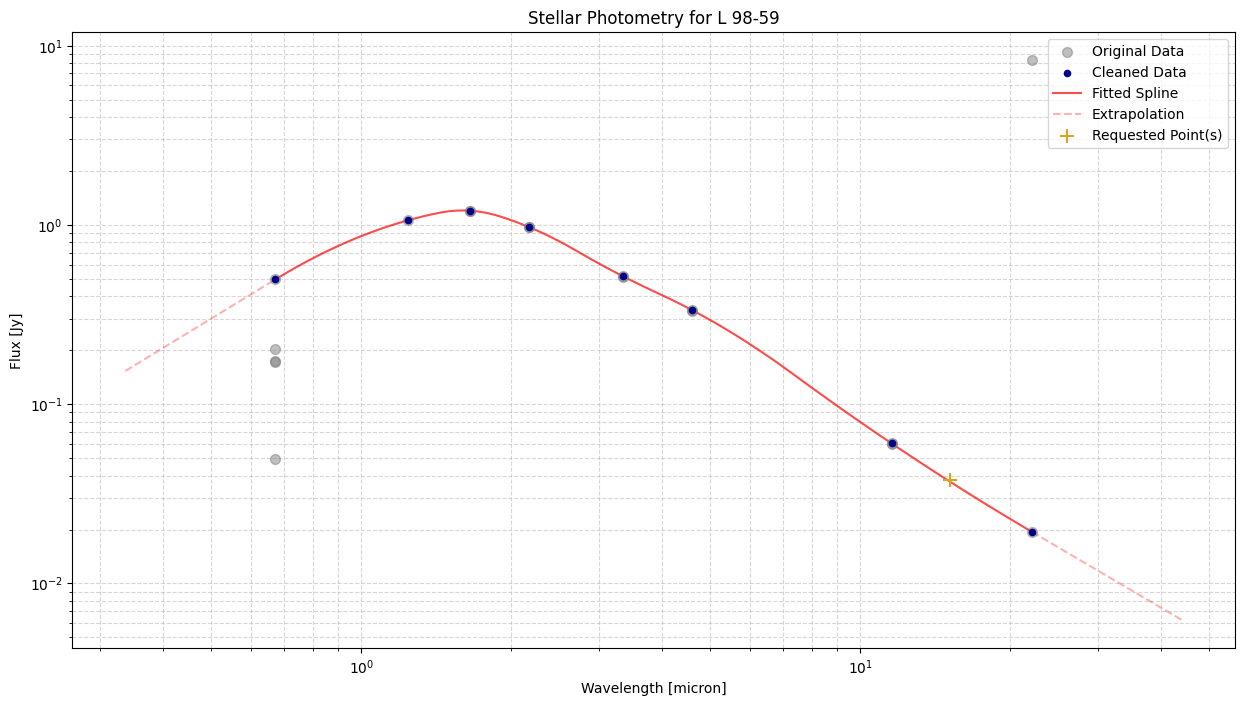

In [1]:
from oplanet import *
from oakley import *

flux_jy = get_photometry_jy("L 98-59", "F1500W", show=True)

With `SFilters`, one can then estimate the number of photons this flux amounts to, through the JWST F1500W filter.

In [ ]:
sfilter = SFilter("F1500W")
c = 3e8
Flambda = flux_jy * 1e-26 * c / sfilter.wl_pivot**2
N_electrons = sfilter.get_nphotons(
    Flambda, A=25.4, exposure_time=3600 # A is telescope effective area in m^2
) # since QE is inscluded in SVO filter profiles, this is a number of electrons actually

Message("Number of electrons detected in 1 hour:").list({
    "Flux (Jy)": flux_jy,
    "Flux (W/m^2/m)": Flambda,
    "Number of electrons": f"{N_electrons:_.0f}"
})

[i] Number of electrons detected in 1 hour:
 > Flux (Jy):           0.038000081000072336
 > Flux (W/m^2/m):      5.02404648582855e-10
 > Number of electrons: 3_772_167_597


## List of properties
```python
# 1. Available @property for SFilter
sfilter = SFilter("F1500W")
sfilter.name                  # filter short name
sfilter.id                    # unique SVO identifier
sfilter.wl_mean               # mean wavelength (m)
sfilter.wl_pivot              # pivot wavelength (m)
sfilter.wl_eff                # effective wavelength (m)
sfilter.effective_bandwidth  # normalized bandwidth (m)
sfilter.bandwidth             # bandwidth (m)
sfilter.fwhm                  # full width at half maximum (m)
sfilter.wl_min                # min wavelength at 1% transmission (m)
sfilter.wl_max                # max wavelength at 1% transmission (m)
sfilter.wl_central            # central wavelength (m)
sfilter.wl_peak               # peak-transmission wavelength (m)
sfilter.detector_type         # detector type
sfilter.wl                    # transmission-curve wavelengths (m)
sfilter.tr                    # transmission-curve values

# 2. Available @property for NSystem
system = NSystem("Beta Pictoris")
system.columns           # available columns (suffixes grouped)
system.name              # system/star name
system.distance_pc       # distance (pc)
system.parallax_mas      # parallax (mas)
system.ra                # right ascension (deg)
system.dec               # declination (deg)
system.aliases           # Simbad aliases
system.reference_date    # reference year
system.reference_author  # reference author
system.reference_url     # reference URL
system.reference         # formatted reference string
system.star              # NStar view
system.a                 # alias for system.star
system.A                 # alias for system.star
system.n_planets         # number of detected planets
system.planets           # list of NPlanet objects
system.b                 # planet b
system.c                 # planet c
system.d                 # planet d
system.e                 # planet e
system.f                 # planet f
system.g                 # planet g
system.h                 # planet h
system.i                 # planet i
system.j                 # planet j (lol)

# 3. Available @property for NStar
star = system.star
# NStar inherits NSystem properties and adds:
star.age_myr          # age (Myr)
star.mass_solar       # stellar mass (Msun)
star.radius_solar     # stellar radius (Rsun)
star.luminosity_solar # stellar luminosity (Lsun)
star.Teff_k           # effective temperature (K)
star.metallicity_dex  # metallicity (dex)
star.spectral_type    # spectral type
star.system           # NSystem view for the same chosen row

# 4. Available @property for NPlanet
planet = system.b
# NPlanet inherits NSystem properties and adds:
planet.name               # full planet name
planet.letter             # planet letter
planet.discovery_year     # discovery year
planet.discovery_method   # discovery method
planet.orbital_period_yrs # orbital period (yr)
planet.mass_sini_mjup     # M sin(i) (Mjup)
planet.mass_mjup          # planet mass (Mjup)
planet.sma_au             # semi-major axis (AU)
planet.eccentricity       # orbital eccentricity
planet.inclination_deg    # inclination (deg)
planet.arg_periastron_deg # argument of periastron (deg)
planet.time_periastron_jd # time of periastron (JD)
planet.rv_amplitude_ms    # RV amplitude (m/s)
planet.radius_rjup        # radius (Rjup)
planet.star               # NStar view for the same chosen row
planet.system             # NSystem view for the same chosen row
```